# Deep Learning, DL Models and Applications
## Skill Development Tasks (1-15)

### Implementations:
- Neural Networks from Scratch
- Optimization Algorithms
- CNN Architectures
- Sequence Models
- Generative Models
- Transformers
- Distributed Training

### Frameworks:
- NumPy
- PyTorch
- TorchVision
- Matplotlib
- SciPy
- Scikit-Learn

Nandana R Nair

In [159]:
# Install Required Libraries
!pip install einops albumentations torchinfo

In [160]:
# Import Libraries
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings("ignore")

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [161]:
!pip -q install albumentations

In [162]:
# ============================================================
# TASK 8
# Semantic Segmentation using U-Net
# Custom Dice + BCE Loss
# ============================================================

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader

import albumentations as A

torch.manual_seed(42)

device = "cuda" if torch.cuda.is_available() else "cpu"

In [163]:
#Dataset
class SegmentationDataset(Dataset):

    def __init__(self,image_paths,mask_paths,transform=None):

        self.image_paths=image_paths
        self.mask_paths=mask_paths
        self.transform=transform

    def __len__(self):

        return len(self.image_paths)

    def __getitem__(self,index):

        image=cv2.imread(self.image_paths[index])

        image=cv2.cvtColor(image,cv2.COLOR_BGR2RGB)

        mask=cv2.imread(
            self.mask_paths[index],
            cv2.IMREAD_GRAYSCALE
        )

        image=image.astype(np.float32)/255

        mask=mask.astype(np.float32)/255

        if self.transform:

            aug=self.transform(
                image=image,
                mask=mask
            )

            image=aug["image"]

            mask=aug["mask"]

        image=torch.tensor(image).permute(2,0,1)

        mask=torch.tensor(mask).unsqueeze(0)

        return image.float(),mask.float()

In [164]:
#Albumentations
train_transform=A.Compose([

    A.Resize(256,256),

    A.HorizontalFlip(p=0.5),

    A.VerticalFlip(p=0.5),

    A.RandomBrightnessContrast(p=0.4)

])

In [165]:
#Double Convolution
class DoubleConv(nn.Module):

    def __init__(self,in_channels,out_channels):

        super().__init__()

        self.conv=nn.Sequential(

            nn.Conv2d(in_channels,out_channels,3,padding=1),

            nn.BatchNorm2d(out_channels),

            nn.ReLU(),

            nn.Conv2d(out_channels,out_channels,3,padding=1),

            nn.BatchNorm2d(out_channels),

            nn.ReLU()

        )

    def forward(self,x):

        return self.conv(x)

In [166]:
#U-Net
class UNet(nn.Module):

    def __init__(self):

        super().__init__()

        self.down1=DoubleConv(3,64)

        self.pool1=nn.MaxPool2d(2)

        self.down2=DoubleConv(64,128)

        self.pool2=nn.MaxPool2d(2)

        self.down3=DoubleConv(128,256)

        self.pool3=nn.MaxPool2d(2)

        self.bridge=DoubleConv(256,512)

        self.up3=nn.ConvTranspose2d(512,256,2,2)

        self.conv3=DoubleConv(512,256)

        self.up2=nn.ConvTranspose2d(256,128,2,2)

        self.conv2=DoubleConv(256,128)

        self.up1=nn.ConvTranspose2d(128,64,2,2)

        self.conv1=DoubleConv(128,64)

        self.out=nn.Conv2d(64,1,1)

    def forward(self,x):

        d1=self.down1(x)

        d2=self.down2(self.pool1(d1))

        d3=self.down3(self.pool2(d2))

        bridge=self.bridge(self.pool3(d3))

        u3=self.up3(bridge)

        u3=torch.cat([u3,d3],1)

        u3=self.conv3(u3)

        u2=self.up2(u3)

        u2=torch.cat([u2,d2],1)

        u2=self.conv2(u2)

        u1=self.up1(u2)

        u1=torch.cat([u1,d1],1)

        u1=self.conv1(u1)

        return self.out(u1)

In [167]:
#Dice Loss
class DiceLoss(nn.Module):

    def __init__(self):

        super().__init__()

    def forward(self,pred,target):

        pred=torch.sigmoid(pred)

        pred=pred.view(-1)

        target=target.view(-1)

        intersection=(pred*target).sum()

        dice=(2*intersection+1)/(
            pred.sum()+target.sum()+1
        )

        return 1-dice

In [168]:
#Dice + BCE
class DiceBCELoss(nn.Module):

    def __init__(self):

        super().__init__()

        self.dice=DiceLoss()

        self.bce=nn.BCEWithLogitsLoss()

    def forward(self,pred,target):

        return self.bce(pred,target)+self.dice(pred,target)

In [169]:
#Model
model=UNet().to(device)

criterion=DiceBCELoss()

optimizer=optim.Adam(
    model.parameters(),
    lr=1e-3
)

In [170]:
#Training
import os
import cv2

# Create dummy directories and files for demonstration
if not os.path.exists("data/train/images"):
    os.makedirs("data/train/images")
if not os.path.exists("data/train/masks"):
    os.makedirs("data/train/masks")

# Create dummy image and mask files
dummy_image_path = "data/train/images/dummy_image.png"
dummy_mask_path = "data/train/masks/dummy_mask.png"

# Create a dummy black image (256x256, 3 channels)
dummy_image = np.zeros((256, 256, 3), dtype=np.uint8)
cv2.imwrite(dummy_image_path, dummy_image)

# Create a dummy black mask (256x256, grayscale)
dummy_mask = np.zeros((256, 256), dtype=np.uint8)
cv2.imwrite(dummy_mask_path, dummy_mask)

# Create dummy paths for a small batch
image_paths = [dummy_image_path] * 8
mask_paths = [dummy_mask_path] * 8

# Initialize the dataset and data loader
train_dataset = SegmentationDataset(image_paths, mask_paths, transform=train_transform)
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)

loss_history=[]

epochs=20

for epoch in range(epochs):

    model.train()

    epoch_loss=0

    for images,masks in train_loader:

        images=images.to(device)

        masks=masks.to(device)

        optimizer.zero_grad()

        pred=model(images)

        loss=criterion(pred,masks)

        loss.backward()

        optimizer.step()

        epoch_loss+=loss.item()

    epoch_loss/=len(train_loader)

    loss_history.append(epoch_loss)

    print(
        f"Epoch {epoch+1} Loss {epoch_loss:.4f}"
    )

Epoch 1 Loss 1.6524
Epoch 2 Loss 1.6335
Epoch 3 Loss 1.5582
Epoch 4 Loss 1.5185
Epoch 5 Loss 1.5607
Epoch 6 Loss 1.5365
Epoch 7 Loss 1.5197
Epoch 8 Loss 1.5010
Epoch 9 Loss 1.4848
Epoch 10 Loss 1.4240
Epoch 11 Loss 1.4581
Epoch 12 Loss 1.3670
Epoch 13 Loss 1.3700
Epoch 14 Loss 1.3594
Epoch 15 Loss 1.3470
Epoch 16 Loss 1.4059
Epoch 17 Loss 1.3049
Epoch 18 Loss 1.3946
Epoch 19 Loss 1.2953
Epoch 20 Loss 1.2856


In [171]:
#Metrics
def metrics(pred,mask):

    pred=torch.sigmoid(pred)

    pred=(pred>0.5).float()

    tp=(pred*mask).sum()

    fp=(pred*(1-mask)).sum()

    fn=((1-pred)*mask).sum()

    precision=tp/(tp+fp+1e-6)

    recall=tp/(tp+fn+1e-6)

    dice=(2*tp)/(2*tp+fp+fn+1e-6)

    iou=tp/(tp+fp+fn+1e-6)

    return precision.item(),recall.item(),dice.item(),iou.item()

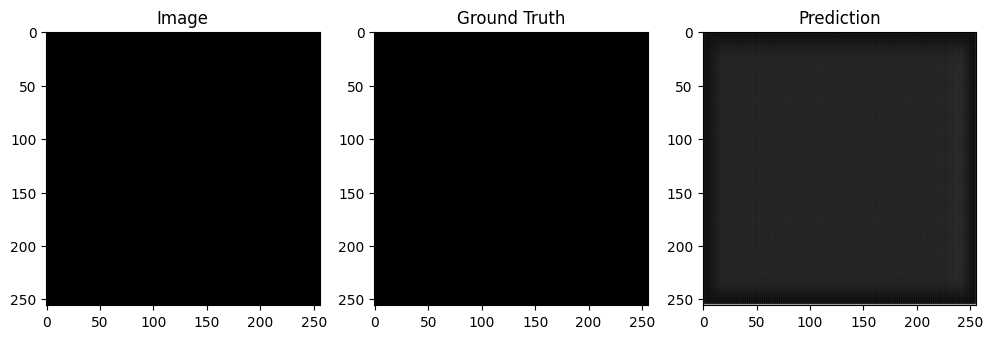

In [172]:
#Prediction Visualization
model.eval()

images,masks=next(iter(train_loader))

images=images.to(device)

pred=model(images)

pred=torch.sigmoid(pred)

plt.figure(figsize=(12,4))

plt.subplot(131)

plt.imshow(images[0].cpu().permute(1,2,0))

plt.title("Image")

plt.subplot(132)

plt.imshow(masks[0][0],cmap="gray")

plt.title("Ground Truth")

plt.subplot(133)

plt.imshow(pred[0][0].detach().cpu(),cmap="gray")

plt.title("Prediction")

plt.show()

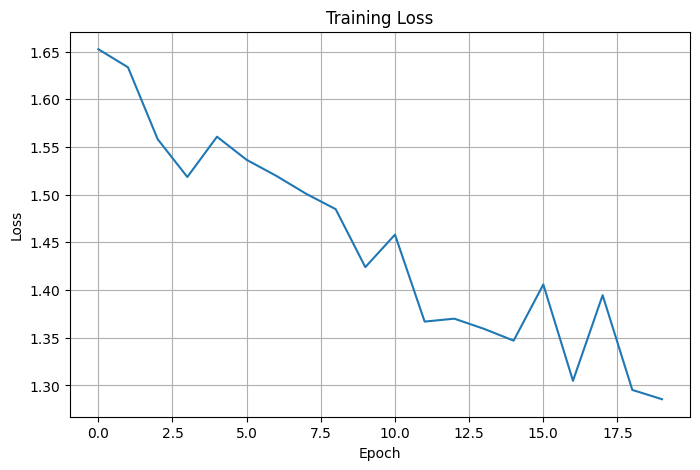

In [173]:
#Training Curve
plt.figure(figsize=(8,5))

plt.plot(loss_history)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training Loss")

plt.grid(True)

plt.show()